In [5]:
!pip install xarray netCDF4
!pip install timm torchinfo -q
!pip install zarr dask scipy pyyaml
!pip install h5netcdf cfgrib cdsapi leafmap
!pip install --upgrade xarray zarr dask numcodecs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 133.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 94.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 kB 554.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 666.8/666.8 kB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.4/21.4 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.5/91.5 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 104.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 113.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8

In [6]:
# @title 1. Set up & Imports
import os
import glob
import yaml
import math
import cdsapi
import shutil

import numpy as np
import xarray as xr
import pandas as pd

from tqdm.auto import tqdm

import gc
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [4]:
# Connect drive
ROOT = '/content/drive'
from google.colab import drive
drive.mount(ROOT, force_remount=True)

Mounted at /content/drive


In [ ]:
# Save 2 files with same folder
ENV_PATH = f'{ROOT}/MyDrive/.env'
CONFIG_PATH = f'{ROOT}/MyDrive/config.yaml'

print(os.path.exists(ENV_PATH))
print(os.path.exists(CONFIG_PATH))
try:
  with open(ENV_PATH, 'r') as f:
        lines = f.readlines()
        for line in lines:
            if 'url:' in line:
                URL = line.split('url:')[1].strip().strip("'").strip('"')
            elif 'key:' in line:
                KEY = line.split('key:')[1].strip().strip("'").strip('"')
except Exception as e:
  print(f"ENV error : {e}")

# Tạo file .cdsapirc trong thư mục root
with open('/root/.cdsapirc', 'w') as f:
    f.write(f"url: {URL}\n")
    f.write(f"key: {KEY}")

def reload_config():
  try:
    with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
        config = yaml.safe_load(f)
        print(config.keys())
  except Exception as e:
    print(f"Config error : {e}")
  return config

CONFIG = reload_config()
PARAMETERS = CONFIG['PARAMETERS']


True
True
Đã tạo file cấu hình .cdsapirc thành công.
dict_keys(['PARAMETERS', 'LOADER', 'MODEL', 'TRAIN', 'LOGS'])


In [ ]:
MONTHS = ['01', '02', '03', '04', '05', '06',
          '07', '08', '09', '10', '11', '12']
DAYS = ['01', '02', '03', '04', '05', '06',
        '07', '08', '09', '10', '11', '12',
        '13', '14', '15', '16', '17', '18',
        '19', '20', '21', '22', '23', '24',
        '25', '26', '27', '28', '29', '30', '31' ]

In [ ]:
# @title 4. Data Downloader

def process_weather_data(name_zarr: str = 'ERA5',
                         output_path: str = '/content/drive/MyDrive/ERA5_Data/test',
                         variables: list = ['2m_temperature'],
                         years: list = ['2023', '2024', '2025'],
                         months: list =  [str(i).zfill(2) for i in range(1, 13)],
                         days: list = [str(i).zfill(2) for i in range(1, 31)],
                         step_hours: int = 6,
                         area: list = [23.5, 102, 8.5, 110]):

    '''
      Aguments:
      * output_path: vị trí lưu trữ file zarr (dữ liệu đầu ra cuối cùng)
      * variables: danh sách các biến cần lấy dữ liệu
      * years: danh sách năm cần lấy dữ liệu
      * months: danh sách tháng cần lấy dữ liệu
      * days: danh sách ngày cần lấy dữ liệu
      * step_hours: số giờ/ bước để lấy dữ liệu
      * area: vùng lấy dữ liệu
    '''
    os.makedirs(output_path, exist_ok=True)
    times = [f"{h:02d}:00" for h in range(0, 24, step_hours)]

    c = cdsapi.Client()
    temp_dir = "/content/temp_weather_data"
    os.makedirs(temp_dir, exist_ok=True)

    downloaded_files = []

    print("🚀 Bắt đầu quy trình tải dữ liệu...")
    for var in variables:
        target_file = os.path.join(temp_dir, f"era5_{var}.nc")
        print(f"⏳ Đang tải dữ liệu {var}...")

        try:
            c.retrieve(
                'reanalysis-era5-single-levels',
                {
                    'product_type': 'reanalysis',
                    'format': 'netcdf',
                    'variable': [var],
                    'year': years,
                    'month': months,
                    'day': days,
                    'time': times,
                    'area': area,
                },
                target_file)
            downloaded_files.append(target_file)
            print(f"✅ Hoàn thành {var}")
        except Exception as e:
            print(f"❌ Lỗi khi tải năm {var}: {e}")
            continue
    try:
        merged_dataset = xr.open_mfdataset(downloaded_files, combine='by_coords')
        merged_dataset.chunk('auto')
        merged_dataset.to_zarr(os.path.join(output_path, name_zarr), mode ='w')
        print("🎉 Quá trình lưu hoàn tất!")
        merged_dataset.close()
    except Exception as e:
        print(f"❌ Lỗi trong quá trình gộp hoặc lưu file: {e}")
    finally:
        shutil.rmtree(temp_dir)

# if __name__ == "__main__":
#     # reload config
#     config = reload_config()
#     PARAMETERS = config['PARAMETERS']

#     process_weather_data(name_zarr= PARAMETERS['NAME_ZARR_FOLDER'],
#                          output_path= PARAMETERS['OUTPUT_PATH'],
#                          variables= PARAMETERS['VARIABLES'],
#                          years= PARAMETERS['YEARS'],
#                          months= MONTHS,
#                          days= DAYS,
#                          step_hours= PARAMETERS['STEP_HOURS'],
#                          area= PARAMETERS['AREA'])

In [ ]:
ZARR_PATH = os.path.join(PARAMETERS['OUTPUT_PATH'], PARAMETERS['NAME_ZARR_FOLDER'])
try:
    ds_zarr_check = xr.open_zarr(ZARR_PATH, consolidated=True)
    print(ds_zarr_check)
except Exception as e:
    print(f"❌ Lỗi: {e}")

<xarray.Dataset> Size: 177MB
Dimensions:     (valid_time: 4384, latitude: 61, longitude: 33)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 35kB 2023-01-01 ... 2025-12-31T18...
    expver      (valid_time) <U4 70kB dask.array<chunksize=(4384,), meta=np.ndarray>
  * latitude    (latitude) float64 488B 23.5 23.25 23.0 22.75 ... 9.0 8.75 8.5
  * longitude   (longitude) float64 264B 102.0 102.2 102.5 ... 109.5 109.8 110.0
    number      int64 8B ...
Data variables:
    sp          (valid_time, latitude, longitude) float32 35MB dask.array<chunksize=(2192, 31, 17), meta=np.ndarray>
    t2m         (valid_time, latitude, longitude) float32 35MB dask.array<chunksize=(2192, 31, 17), meta=np.ndarray>
    tp          (valid_time, latitude, longitude) float32 35MB dask.array<chunksize=(2192, 31, 17), meta=np.ndarray>
    u10         (valid_time, latitude, longitude) float32 35MB dask.array<chunksize=(2192, 31, 17), meta=np.ndarray>
    v10         (valid_time, latitude, longitude) float

In [ ]:
class WeatherDataset(Dataset):
    def __init__(self, data_array, seq_len, pred_len, img_size=(256, 256)):
        """
        data_array: Tensor chứa dữ liệu đã chuẩn hóa, shape (Time, Channels, Lat, Lon)
        """
        self.data = data_array
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.img_size = img_size

        self.num_samples = len(self.data) - self.seq_len - self.pred_len + 1

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # Lấy chuỗi đầu vào (từ idx đến idx + seq_len)
        x = self.data[idx : idx + self.seq_len]

        # Lấy chuỗi mục tiêu dự đoán (từ idx + seq_len đến idx + seq_len + pred_len)
        y = self.data[idx + self.seq_len : idx + self.seq_len + self.pred_len]

        # Resize không gian về 256x256
        # x, y đang có shape (seq/pred_len, Channels, Lat, Lon) -> F.interpolate sẽ coi seq_len như Batch
        x = F.interpolate(x, size=self.img_size, mode='bilinear', align_corners=False)
        y = F.interpolate(y, size=self.img_size, mode='bilinear', align_corners=False)

        return x, y

def prepare_dataloaders(zarr_path,
                        variables,
                        seq_len,
                        pred_len,
                        batch_size=8,
                        img_size=(256, 256)):
    print("Đang đọc và chuẩn hóa dữ liệu...")
    dataset = xr.open_zarr(zarr_path)

    data_list = []
    for var in variables:
        # Chuyển đổi sang numpy và xử lý NaN
        var_data = dataset[var].values
        var_data = np.nan_to_num(var_data)

        # Chuẩn hóa Z-score cho toàn bộ chuỗi thời gian của biến này
        mean = np.mean(var_data)
        std = np.std(var_data)
        if std == 0: std = 1
        var_data = (var_data - mean) / std

        data_list.append(var_data)

    # Gộp lại thành tensor có shape: (Time, Channels, Lat, Lon)
    full_data = np.stack(data_list, axis=1)
    full_data = torch.tensor(full_data, dtype=torch.float32)

    total_time_steps = len(full_data)
    print(f"Tổng số mốc thời gian: {total_time_steps}")

    # ---------------------------------------------------------
    # CHIA DỮ LIỆU THEO TRÌNH TỰ THỜI GIAN (Tỉ lệ 8:1:1)
    # ---------------------------------------------------------
    train_end = int(total_time_steps * 0.8)
    val_end = int(total_time_steps * 0.9)

    train_data = full_data[:train_end]
    val_data = full_data[train_end:val_end]
    test_data = full_data[val_end:]

    print(f"Kích thước tập Train: {len(train_data)} mốc thời gian")
    print(f"Kích thước tập Val:   {len(val_data)} mốc thời gian")
    print(f"Kích thước tập Test:  {len(test_data)} mốc thời gian")

    # Khởi tạo Datasets
    train_dataset = WeatherDataset(train_data, seq_len, pred_len, img_size)
    val_dataset = WeatherDataset(val_data, seq_len, pred_len, img_size)
    test_dataset = WeatherDataset(test_data, seq_len, pred_len, img_size)

    # Khởi tạo DataLoaders
    # Lưu ý: shuffle=True cho Train (vì các chuỗi độc lập), nhưng False cho Val/Test
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    return train_loader, val_loader, test_loader


In [ ]:
# @title 5. Dataset & DataLoader

CONFIG = reload_config()
LOADER = CONFIG['LOADER']
PARAMETERS = CONFIG['PARAMETERS']
ZARR_PATH = os.path.join(PARAMETERS['OUTPUT_PATH'], PARAMETERS['NAME_ZARR_FOLDER'])

SEQ_LEN = LOADER['SEQ_LEN']
PRED_LEN = LOADER['PRED_LEN']
IMG_SIZE = LOADER['IMG_SIZE']
BATCH_SIZE = LOADER['BATCH_SIZE']

target_vars = ['t2m', 'u10', 'v10', 'tp', 'sp']

# if  __name__ == "__main__":
train_loader, valid_loader, test_loader = prepare_dataloaders(
    zarr_path=ZARR_PATH,
    variables=target_vars,
    seq_len=SEQ_LEN,
    pred_len=PRED_LEN,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE)


dict_keys(['PARAMETERS', 'LOADER', 'MODEL', 'TRAIN', 'LOGS'])
Đang đọc và chuẩn hóa dữ liệu...
Tổng số mốc thời gian: 4384
Kích thước tập Train: 3507 mốc thời gian
Kích thước tập Val:   438 mốc thời gian
Kích thước tập Test:  439 mốc thời gian


In [ ]:


class SwinV2WeatherForecaster(nn.Module):
    def __init__(self,
                 model_name,
                 pretrained,
                 num_channels,
                 seq_len,
                 pred_len,
                 img_size=(256, 256)):
        super().__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.num_channels = num_channels

        in_chans_flat = seq_len * num_channels
        out_chans_flat = pred_len * num_channels

        self.encoder = timm.create_model(
            'swinv2_tiny_window16_256',
            pretrained=pretrained,
            in_chans=in_chans_flat,
            num_classes=0,
            global_pool=''
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(768, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, out_chans_flat, kernel_size=4, stride=2, padding=1)
        )

    def forward(self, x):
        B, S, C, H, W = x.shape
        x = x.view(B, S * C, H, W)

        features = self.encoder(x)

        # Xử lý định dạng trả về của TIMM
        if len(features.shape) == 3:
            _, L, Dim = features.shape
            spatial_size = int(L ** 0.5)
            features = features.view(B, spatial_size, spatial_size, Dim).permute(0, 3, 1, 2)
        elif len(features.shape) == 4:
            features = features.permute(0, 3, 1, 2)

        out = self.decoder(features)
        out = out.view(B, self.pred_len, self.num_channels, H, W)

        return out

In [ ]:
# @title 6. Load Model

from torchinfo import summary
# reload config
CONFIG = reload_config()
MODEL = CONFIG['MODEL']
NAME_MODEL = MODEL['NAME']


sample_x, sample_y = next(iter(train_loader))
IN_CHANNELS = sample_x.shape[2]


print(f"🚀 ĐANG BUILD MÔ HÌNH: {MODEL['NAME']}")
model_tiny = SwinV2WeatherForecaster(
    model_name=NAME_MODEL,
    pretrained=True, # Sử dụng trọng số pre-trained ImageNet
    num_channels=IN_CHANNELS,
    seq_len=SEQ_LEN,
    pred_len=PRED_LEN,
    img_size=(IMG_SIZE, IMG_SIZE)
)
summary(
    model_tiny,
    input_size=(2, SEQ_LEN, IN_CHANNELS, IMG_SIZE, IMG_SIZE),
    col_names=["input_size", "output_size", "num_params"],
    depth=4 # Độ sâu chi tiết hiển thị
)

# --- THỬ NGHIỆM 2: SWINV2 BASE (Nặng hơn, chính xác cao hơn) ---
# print("\n🚀 ĐANG BUILD MÔ HÌNH: SwinV2 Base")
# model_base = SwinV2WeatherForecaster(
#     model_name='swinv2_base_window12to16_192to256_22kft1k',
#     pretrained=True,
#     num_channels=IN_CHANNELS,
#     seq_len=SEQ_LEN,
#     pred_len=PRED_LEN,
#     img_size=(IMG_SIZE, IMG_SIZE)
# )

dict_keys(['PARAMETERS', 'LOADER', 'MODEL', 'TRAIN', 'LOGS'])
🚀 ĐANG BUILD MÔ HÌNH: swinv2_base_window16_256


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/119M [00:00<?, ?B/s]

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #
SwinV2WeatherForecaster                                 [2, 16, 5, 256, 256]      [2, 4, 5, 256, 256]       --
├─SwinTransformerV2: 1-1                                [2, 80, 256, 256]         [2, 8, 8, 768]            --
│    └─PatchEmbed: 2-1                                  [2, 80, 256, 256]         [2, 64, 64, 96]           --
│    │    └─Conv2d: 3-1                                 [2, 80, 256, 256]         [2, 96, 64, 64]           122,976
│    │    └─LayerNorm: 3-2                              [2, 64, 64, 96]           [2, 64, 64, 96]           192
│    └─Sequential: 2-2                                  [2, 64, 64, 96]           [2, 8, 8, 768]            --
│    │    └─SwinTransformerV2Stage: 3-3                 [2, 64, 64, 96]           [2, 64, 64, 96]           --
│    │    │    └─Identity: 4-1                          [2, 64, 64, 96]           [2, 64, 64, 96]    

In [ ]:
CONFIG = reload_config()
LOGS = CONFIG['LOGS']
TRAIN = CONFIG['TRAIN']
PARAMETERS = CONFIG['PARAMETERS']


# Cấu hình cho thử nghiệm hiện tại (Experiment 01)
experiment_args = {
    "experiment_name": LOGS['NAME'],
    "model_name": NAME_MODEL,
    "dataset": PARAMETERS['NAME_ZARR_FOLDER'],
    "variables": PARAMETERS['TARGET_VARS'],

    # Cấu hình dữ liệu
    "seq_len": SEQ_LEN,
    "pred_len": PRED_LEN,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,

    # Cấu hình huấn luyện
    "epochs": TRAIN['EPOCHS'],
    "patience": TRAIN['PATIENCE'],
    "learning_rate": TRAIN['LEARNING_RATE'],
    "weight_decay": TRAIN['WEIGHT_DECAY'],

    # Đường dẫn lưu trữ (Thay đổi tên thư mục con theo tên thử nghiệm)
    "log_dir": LOGS['DIR'] + LOGS['NAME']
}

dict_keys(['PARAMETERS', 'LOADER', 'MODEL', 'TRAIN', 'LOGS'])


In [ ]:
import os
import json
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

def train_weather_model_with_ui(
    model,
    train_loader,
    valid_loader,
    config
):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    # 1. THIẾT LẬP THƯ MỤC
    log_dir = config["log_dir"]
    os.makedirs(log_dir, exist_ok=True)

    args_save_path = os.path.join(log_dir, 'args.json')
    history_csv_path = os.path.join(log_dir, 'training_history.csv')
    best_model_path = os.path.join(log_dir, 'best_model.pth')
    last_model_path = os.path.join(log_dir, 'last_model.pth')

    with open(args_save_path, 'w', encoding='utf-8') as f:
        json.dump(config, f, indent=4, ensure_ascii=False)

    # 2. KHỞI TẠO THAM SỐ
    epochs = config["epochs"]
    patience = config["patience"]

    optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"], weight_decay=config["weight_decay"])
    criterion_mse = nn.MSELoss()
    criterion_mae = nn.L1Loss()

    history = {'epoch': [], 'train_mse': [], 'valid_mse': [], 'valid_rmse': [], 'valid_mae': []}
    best_val_loss = float('inf')
    patience_counter = 0

    print(f"🖥️ Bắt đầu tiến trình [{config['experiment_name']}] trên {device.type.upper()}...")

    # 3. VÒNG LẶP HUẤN LUYỆN
    epoch_pbar = tqdm(range(1, epochs + 1), desc="📊 Tổng tiến trình", colour='green')

    for epoch in epoch_pbar:
        # --- PHASE TRAIN ---
        model.train()
        train_loss_accum = 0.0
        train_pbar = tqdm(train_loader, desc=f"🚀 Train [Epoch {epoch}]", leave=False, colour='blue')

        for inputs, targets in train_pbar:
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            predictions = model(inputs)
            loss = criterion_mse(predictions, targets)
            loss.backward()
            optimizer.step()

            train_loss_accum += loss.item() * inputs.size(0)
            train_pbar.set_postfix({'Run_MSE': f"{loss.item():.4f}"})

        avg_train_mse = train_loss_accum / len(train_loader.dataset)

        # --- PHASE VALIDATION ---
        model.eval()
        val_mse_accum, val_mae_accum = 0.0, 0.0
        val_pbar = tqdm(valid_loader, desc=f"🔍 Valid [Epoch {epoch}]", leave=False, colour='yellow')

        with torch.no_grad():
            for inputs, targets in val_pbar:
                inputs, targets = inputs.to(device), targets.to(device)
                predictions = model(inputs)

                mse = criterion_mse(predictions, targets)
                mae = criterion_mae(predictions, targets)

                val_mse_accum += mse.item() * inputs.size(0)
                val_mae_accum += mae.item() * inputs.size(0)

        avg_val_mse = val_mse_accum / len(valid_loader.dataset)
        avg_val_mae = val_mae_accum / len(valid_loader.dataset)
        avg_val_rmse = np.sqrt(avg_val_mse)

        # --- CẬP NHẬT LỊCH SỬ ---
        history['epoch'].append(epoch)
        history['train_mse'].append(avg_train_mse)
        history['valid_mse'].append(avg_val_mse)
        history['valid_rmse'].append(avg_val_rmse)
        history['valid_mae'].append(avg_val_mae)

        # 💡 [QUAN TRỌNG NHẤT]: LƯU FILE CSV NGAY LẬP TỨC SAU MỖI EPOCH
        pd.DataFrame(history).to_csv(history_csv_path, index=False)

        tqdm.write(f"✅ Epoch {epoch:02d} | Train MSE: {avg_train_mse:.5f} | Val MSE: {avg_val_mse:.5f} | Val RMSE: {avg_val_rmse:.5f} | Val MAE: {avg_val_mae:.5f}")
        epoch_pbar.set_postfix({'Best_MSE': f"{best_val_loss if best_val_loss != float('inf') else 0:.4f}", 'Patience': f"{patience_counter}/{patience}"})

        # --- LƯU MÔ HÌNH TỐT NHẤT ---
        if avg_val_mse < best_val_loss:
            tqdm.write(f"   🌟 Cập nhật Best Model (Loss: {avg_val_mse:.5f})")
            best_val_loss = avg_val_mse
            patience_counter = 0
            # Lưu trọng số mô hình tốt nhất ngay lập tức
            torch.save(model.state_dict(), best_model_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                tqdm.write(f"\n🛑 Early Stopping tại Epoch {epoch}.")
                break

    # 4. KẾT THÚC
    epoch_pbar.close()

    # Lưu mô hình ở vòng lặp cuối cùng
    torch.save(model.state_dict(), last_model_path)

    print("\n🎉 HOÀN TẤT HUẤN LUYỆN!")
    print("-" * 50)
    print(f"📦 Dữ liệu thử nghiệm đã lưu tại:\n{log_dir}")
    print("-" * 50)

    # Trả về DataFrame cuối cùng cho hàm gọi
    return pd.DataFrame(history)

In [ ]:
# Gọi hàm với bộ config duy nhất
training_history_df = train_weather_model_with_ui(
    model=model_tiny,
    train_loader=train_loader,
    valid_loader=valid_loader,
    config=experiment_args  # Truyền bộ dictionary vào
)

🖥️ Bắt đầu tiến trình [SwinV2_Base_Window16_Run_01] trên CUDA...


📊 Tổng tiến trình:   0%|          | 0/100 [00:00<?, ?it/s]

🚀 Train [Epoch 1]:   0%|          | 0/872 [00:00<?, ?it/s]

🔍 Valid [Epoch 1]:   0%|          | 0/105 [00:00<?, ?it/s]

✅ Epoch 01 | Train MSE: 0.67880 | Val MSE: 0.75908 | Val RMSE: 0.87125 | Val MAE: 0.52920
   🌟 Cập nhật Best Model (Loss: 0.75908)


...

✅ Epoch 54 | Train MSE: 0.13990 | Val MSE: 0.37674 | Val RMSE: 0.61379 | Val MAE: 0.27684


🚀 Train [Epoch 55]:   0%|          | 0/872 [00:00<?, ?it/s]

🔍 Valid [Epoch 55]:   0%|          | 0/105 [00:00<?, ?it/s]

✅ Epoch 55 | Train MSE: 0.13847 | Val MSE: 0.38778 | Val RMSE: 0.62272 | Val MAE: 0.28732


🚀 Train [Epoch 56]:   0%|          | 0/872 [00:00<?, ?it/s]

In [ ]:
import os
import json
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

def evaluate_and_plot_model(model, test_loader, config):
    print("📊 BẮT ĐẦU MODULE ĐÁNH GIÁ MÔ HÌNH...")
    log_dir = config["log_dir"]
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    sns.set_theme(style="whitegrid") # Cài đặt giao diện biểu đồ chuyên nghiệp

    # ==========================================
    # PHẦN 1: VẼ BIỂU ĐỒ LỊCH SỬ HUẤN LUYỆN
    # ==========================================
    history_path = os.path.join(log_dir, 'training_history.csv')
    if os.path.exists(history_path):
        print("📈 Đang vẽ biểu đồ quá trình huấn luyện...")
        df = pd.read_csv(history_path)

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f"Training History: {config['experiment_name']}", fontsize=16, fontweight='bold')

        # 1.1 Biểu đồ Train vs Valid MSE
        axes[0].plot(df['epoch'], df['train_mse'], label='Train MSE', marker='o', color='royalblue')
        axes[0].plot(df['epoch'], df['valid_mse'], label='Valid MSE', marker='s', color='darkorange')
        axes[0].set_title('Mean Squared Error (MSE)')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].legend()

        # 1.2 Biểu đồ Valid RMSE
        axes[1].plot(df['epoch'], df['valid_rmse'], label='Valid RMSE', marker='^', color='forestgreen')
        axes[1].set_title('Root Mean Squared Error (RMSE)')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('RMSE')
        axes[1].legend()

        # 1.3 Biểu đồ Valid MAE
        axes[2].plot(df['epoch'], df['valid_mae'], label='Valid MAE', marker='d', color='crimson')
        axes[2].set_title('Mean Absolute Error (MAE)')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('MAE')
        axes[2].legend()

        plt.tight_layout()
        history_plot_path = os.path.join(log_dir, 'plot_training_history.png')
        plt.savefig(history_plot_path, dpi=300)
        plt.show()
        print(f"✅ Đã lưu biểu đồ lịch sử tại: {history_plot_path}")
    else:
        print("⚠️ Không tìm thấy file training_history.csv để vẽ biểu đồ.")

    # ==========================================
    # PHẦN 2: ĐÁNH GIÁ TRÊN TẬP TEST (TEST LOADER)
    # ==========================================
    print("\n🔍 Đang chuẩn bị đánh giá trên tập dữ liệu Test chưa từng thấy...")

    # Bắt buộc: Load lại trọng số của mô hình TỐT NHẤT (tránh dùng mô hình bị overfitting ở epoch cuối)
    best_model_path = os.path.join(log_dir, 'best_model.pth')
    if os.path.exists(best_model_path):
        model.load_state_dict(torch.load(best_model_path, map_location=device))
        print("📥 Đã nạp thành công trọng số của Best Model!")
    else:
        print("⚠️ Không tìm thấy file best_model.pth, sẽ sử dụng trọng số hiện tại của mô hình.")

    model = model.to(device)
    model.eval() # Chuyển sang chế độ suy luận

    criterion_mse = nn.MSELoss()
    criterion_mae = nn.L1Loss()

    test_mse_accum, test_mae_accum = 0.0, 0.0

    # Vòng lặp Test
    test_pbar = tqdm(test_loader, desc="Testing", colour='cyan')
    with torch.no_grad():
        for inputs, targets in test_pbar:
            inputs, targets = inputs.to(device), targets.to(device)
            predictions = model(inputs)

            mse = criterion_mse(predictions, targets)
            mae = criterion_mae(predictions, targets)

            test_mse_accum += mse.item() * inputs.size(0)
            test_mae_accum += mae.item() * inputs.size(0)

    # Tính toán chỉ số tổng
    avg_test_mse = test_mse_accum / len(test_loader.dataset)
    avg_test_mae = test_mae_accum / len(test_loader.dataset)
    avg_test_rmse = np.sqrt(avg_test_mse)

    print("\n" + "="*40)
    print(f"🎯 KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST")
    print("="*40)
    print(f"   🔹 Test MSE:  {avg_test_mse:.6f}")
    print(f"   🔹 Test RMSE: {avg_test_rmse:.6f}")
    print(f"   🔹 Test MAE:  {avg_test_mae:.6f}")
    print("="*40)

    # ==========================================
    # PHẦN 3: VẼ BIỂU ĐỒ CHỈ SỐ TEST (BAR CHART)
    # ==========================================
    plt.figure(figsize=(8, 5))
    metrics = ['MSE', 'RMSE', 'MAE']
    values = [avg_test_mse, avg_test_rmse, avg_test_mae]

    # Tạo biểu đồ cột
    ax = sns.barplot(x=metrics, y=values, palette='mako')
    plt.title(f'Test Set Evaluation Metrics\n({config["experiment_name"]})', fontsize=14, fontweight='bold')
    plt.ylabel('Error Value (Càng thấp càng tốt)')

    # Hiển thị giá trị cụ thể trên đầu mỗi cột
    for i, v in enumerate(values):
        ax.text(i, v + (max(values)*0.02), f"{v:.5f}", ha='center', va='bottom', fontweight='bold', fontsize=11)

    plt.tight_layout()
    test_plot_path = os.path.join(log_dir, 'plot_test_metrics.png')
    plt.savefig(test_plot_path, dpi=300)
    plt.show()
    print(f"✅ Đã lưu biểu đồ Test Metrics tại: {test_plot_path}")
    print("\n🎉 MODULE ĐÁNH GIÁ HOÀN TẤT!")

    # Lưu chỉ số Test vào file JSON để sau này tiện so sánh giữa các model
    test_results = {
        "test_mse": avg_test_mse,
        "test_rmse": avg_test_rmse,
        "test_mae": avg_test_mae
    }
    with open(os.path.join(log_dir, 'test_results.json'), 'w') as f:
        json.dump(test_results, f, indent=4)

📊 BẮT ĐẦU MODULE ĐÁNH GIÁ MÔ HÌNH...
📈 Đang vẽ biểu đồ quá trình huấn luyện...


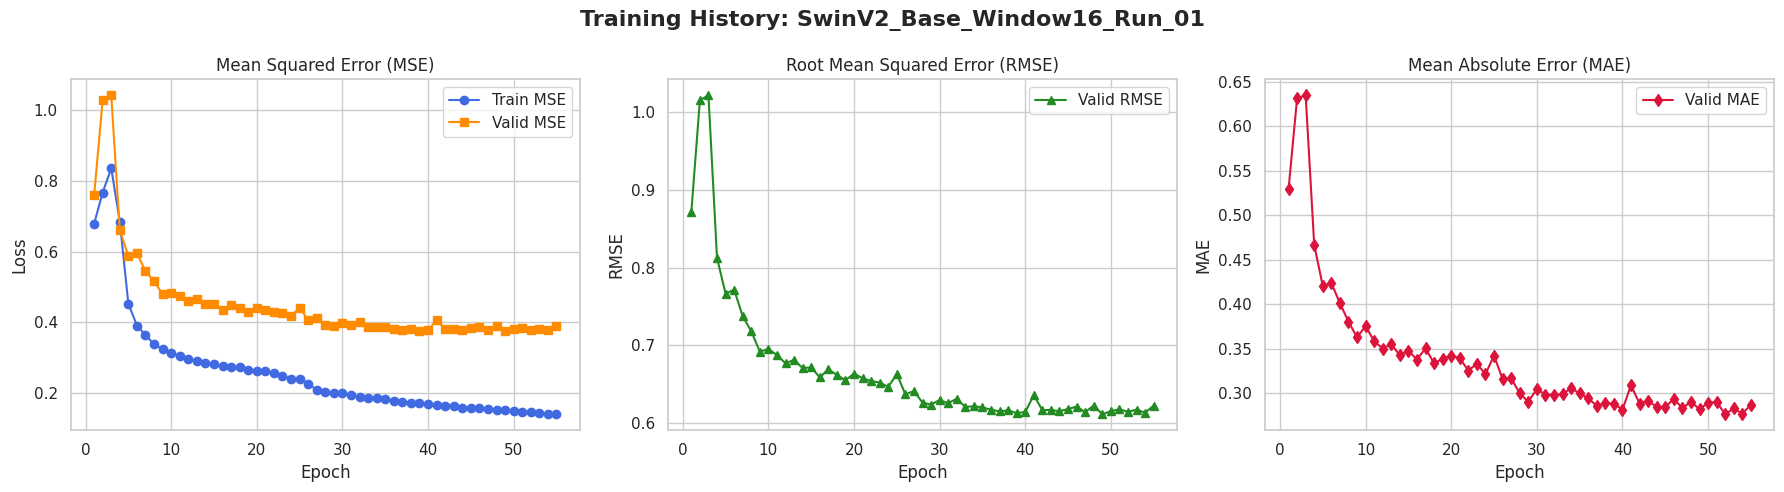

✅ Đã lưu biểu đồ lịch sử tại: /content/drive/MyDrive/Models_ERA5/SwinV2_Base_Window16_Run_01/plot_training_history.png

🔍 Đang chuẩn bị đánh giá trên tập dữ liệu Test chưa từng thấy...
📥 Đã nạp thành công trọng số của Best Model!


Testing:   0%|          | 0/105 [00:00<?, ?it/s]


🎯 KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST
   🔹 Test MSE:  0.318950
   🔹 Test RMSE: 0.564757
   🔹 Test MAE:  0.268154


/tmp/ipykernel_300/1129746406.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=metrics, y=values, palette='mako')


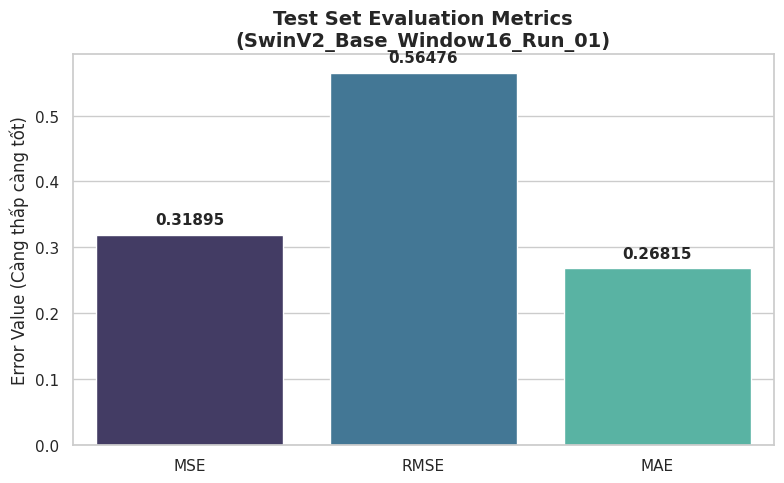

✅ Đã lưu biểu đồ Test Metrics tại: /content/drive/MyDrive/Models_ERA5/SwinV2_Base_Window16_Run_01/plot_test_metrics.png

🎉 MODULE ĐÁNH GIÁ HOÀN TẤT!


In [ ]:
# Gọi module đánh giá với mô hình, test_loader và bộ config đã khai báo
evaluate_and_plot_model(
    model=model_tiny,   # Biến chứa mô hình của bạn
    test_loader=test_loader,
    config=experiment_args  # Chứa thư mục log_dir
)